In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
import matplotlib.pyplot as plt
from math import ceil, floor
from datetime import datetime 
torch.manual_seed(123)
import torchvision
from torchvision.ops import box_convert, complete_box_iou_loss
import math
from torch.utils.data import TensorDataset, DataLoader


# Model definition

In [2]:
device = (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
print(f"Training on device {device}.")

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
net = Net()

Training on device cpu.


## Localization


In [3]:
def localization_loss(y_pred, y_true):
    return torch.where(
        #Todo
        # ...
            # Detection loss
            # ..
            # Bounding box loss
            # ..
            # Classification loss
            # ..
    )

### Load data and preprocessing

In [4]:
def normalize(train, val, test):
    train_tensors = train.tensors[0]  # Get the underlying tensor
    val_tensors = val.tensors[0]  
    test_tensors = test.tensors[0]  

    mean = train_tensors.mean()    # Mean per feature
    std  = train_tensors.std()     # Std per feature
    
    train_norm = (train_tensors - mean) / std 
    val_norm = (val_tensors - mean) / std 
    test_norm = (test_tensors - mean) / std 
    return TensorDataset(train_norm, train.tensors[1]), TensorDataset(val_norm, val.tensors[1]), TensorDataset(test_norm, test.tensors[1])


In [20]:
# TODO
# Load the data
def load_data():
    train = torch.load('data/localization_train.pt', weights_only=False)
    val = torch.load('data/localization_val.pt', weights_only=False)
    test = torch.load('data/localization_test.pt', weights_only=False)
    norm_train, norm_val, norm_test = normalize(train, val, test)
    return train, val, test, norm_train, norm_val, norm_test

train, val, test, norm_train, norm_val, norm_test = load_data()
print(f'Train size: {len(train)}')
print(f'Val size: {len(val)}')
print(f'Test size: {len(test)}')  


labels = train.tensors[1]
# første indeks i label
class_ids = labels[:, 0]
digits = labels[:, -1].long()  # convert to integer

total = len(labels)
no_object = (class_ids == 0).sum().item()
has_object = (class_ids != 0).sum().item()

digit_counts = torch.bincount(digits, minlength=10)
for i in range(10):
    percentage = (digit_counts[i].item() / total) * 100 if total > 0 else 0
    print(f"Digit: {i}: {percentage:.2f}%")

print(f"Color-range: {int(train.tensors[0].min().item())} to {int(train.tensors[0].max().item())}")
print(f"Total samples: {total}")
print(f"No object: {no_object}")
print(f"Has object: {has_object}")
print(f"Image shape: {train.tensors[0].shape[1:]}")
print("Label:", train.tensors[1][0])





Train size: 59400
Val size: 6600
Test size: 11000
Digit: 0: 9.00%
Digit: 1: 19.32%
Digit: 2: 9.03%
Digit: 3: 9.30%
Digit: 4: 8.83%
Digit: 5: 8.23%
Digit: 6: 8.94%
Digit: 7: 9.50%
Digit: 8: 8.84%
Digit: 9: 9.02%
Color-range: 0 to 1
Total samples: 59400
No object: 5400
Has object: 54000
Image shape: torch.Size([1, 48, 60])
Label: tensor([1.0000, 0.6000, 0.2292, 0.3667, 0.4167, 4.0000])


NameError: name 'box_convert' is not defined

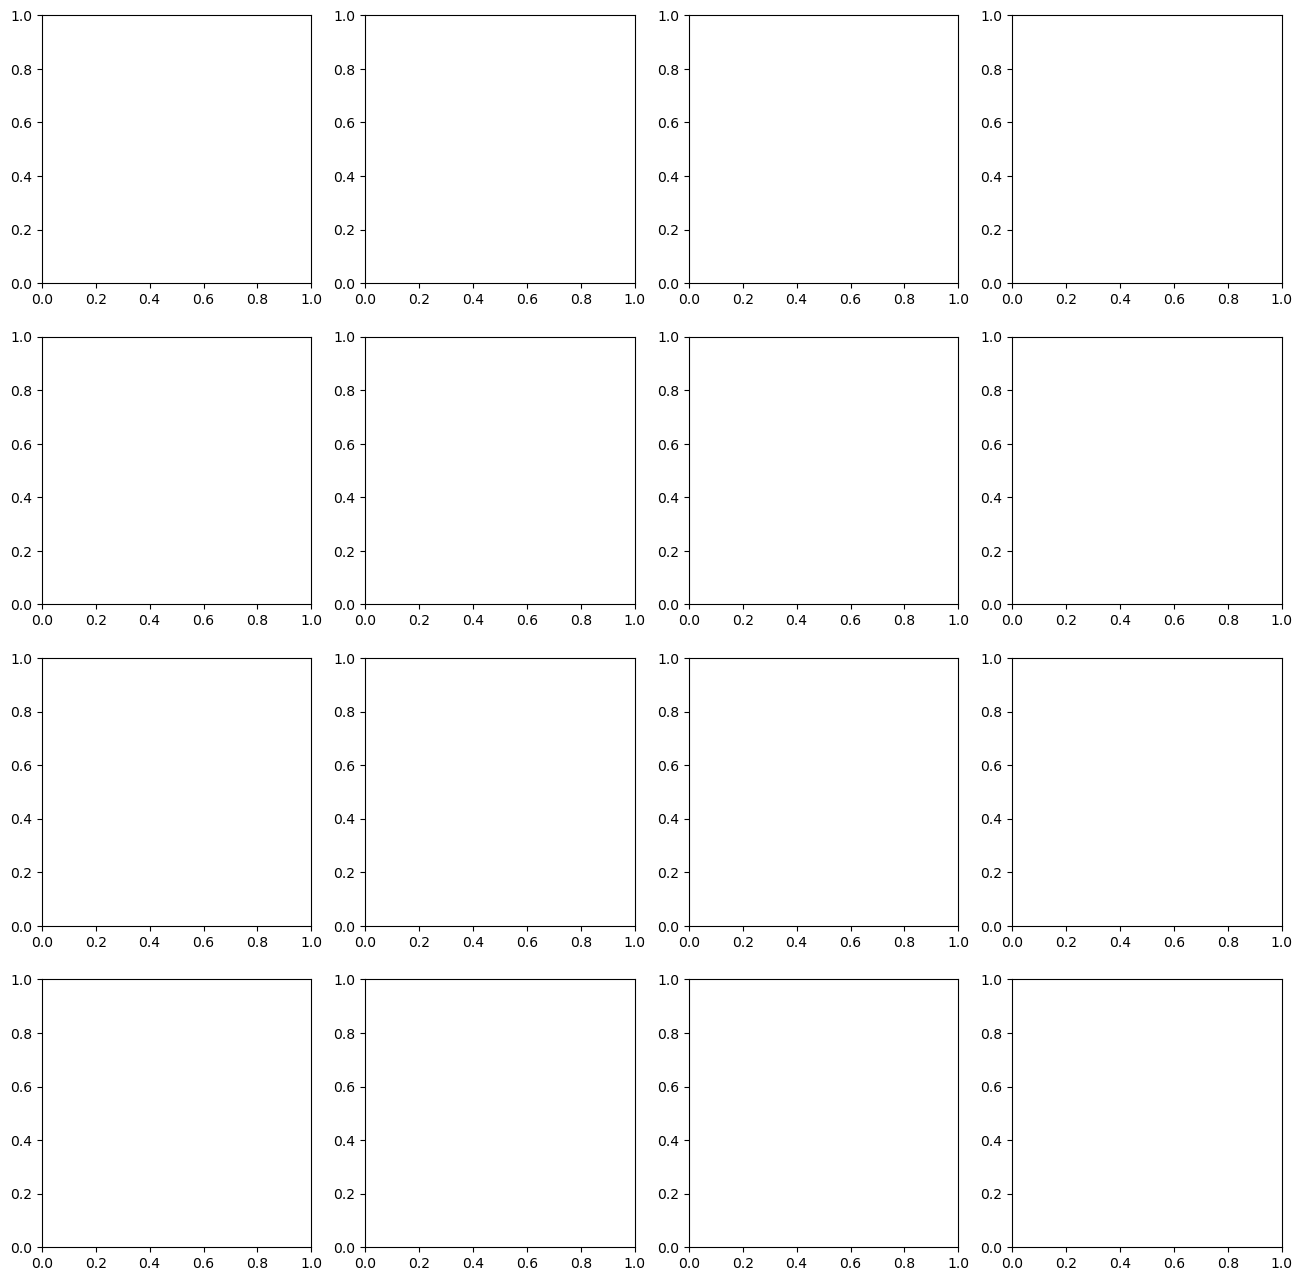

In [ ]:
def get_drawn_image(ds, i=0):
    img = ds.tensors[0][i]          # [1,H,W], float [0,1]
    y   = ds.tensors[1][i].float()  # [6]
    H, W = img.shape[-2], img.shape[-1]

    # y[1:5] = (cx, cy, w, h) normalisert
    box = y[1:5].unsqueeze(0)                   # [1,4]
    box_xyxy = box_convert(box, "cxcywh", "xyxy")  # [1,4] normalisert

    # Skaler til pixels
    box_xyxy = box_xyxy * torch.tensor([W, H, W, H], dtype=torch.float32)

    # Gjør bildet klarere for visning 
    img_u8 = (img.clamp(0,1) * 255).to(torch.uint8).repeat(3, 1, 1)

    if int(y[0].item()) == 0:
        return img_u8.permute(1,2,0).numpy(), int(y[0].item()), '?'

    drawn = torchvision.utils.draw_bounding_boxes(img_u8, box_xyxy, colors="red", width=1)
    return drawn.permute(1,2,0).numpy(), bool(y[0].item()), int(y[-1].item())


def show_samples(ds, n=7):
    cols = 4
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten()  

    for i in range(n):
        img, cls, number = get_drawn_image(ds, i)
        axes[i].imshow(img)
        axes[i].set_title(f"Object: {cls}, Number: {number}")
        axes[i].axis("off")

    # Skjul tomme subplot hvis n ikke fyller gridet
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

show_samples(norm_train, 16)

# Model definition

In [94]:
device = (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
print(f"Training on device {device}.")

num_classes = int(train.tensors[1][:, 5].max().item()) + 1  # +1 because 0-indexed
print(f"{num_classes} classes")

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 9 * 12, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 15)
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
net = Net()

Training on device cuda.
10 classes


## Localization


In [ ]:
def localization_loss(y_pred, y_true, alpha=1.0, beta=1.0, gamma=1.0):
    obj_mask = y_true[:, 0] == 1  # True where an object is present

    # Detection loss (always computed)
    det_loss = nn.BCEWithLogitsLoss()(y_pred[:, 0], y_true[:, 0])

    # Box + class loss ONLY where object is present
    if obj_mask.sum() > 0:  # avoid empty mask
        box_loss = complete_box_iou_loss(
            y_pred[obj_mask, 1:5], 
            y_true[obj_mask, 1:5], 
            reduction='mean'
        )
        cls_loss = nn.CrossEntropyLoss()(
            y_pred[obj_mask, 5:], 
            y_true[obj_mask, 5].long()
        )
    else:
        box_loss = torch.tensor(0.0)
        cls_loss = torch.tensor(0.0)

    return alpha * det_loss + beta * box_loss + gamma * cls_loss

### Training

In [96]:
trainloader = torch.utils.data.DataLoader(train, batch_size=4,
                                          shuffle=True, num_workers=2)

optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

for epoch in range(2):

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = localization_loss(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 2000 == 1999:
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')


[1,  2000] loss: nan
[1,  4000] loss: nan
[1,  6000] loss: nan
[1,  8000] loss: nan


KeyboardInterrupt: 

### Predictions

In [ ]:
# TODO

### Model selection and evaluation

In [ ]:
def intersection(bb1, bb2):

    box1_cxcywh=bb1[1:5]
    box2_cxcywh=bb2[1:5]
    box1 = box_convert(box1_cxcywh.unsqueeze(0), "cxcywh", "xyxy")
    box2 = box_convert(box2_cxcywh.unsqueeze(0), "cxcywh", "xyxy")

    x_min = torch.max(box1[:, 0], box2[:, 0])
    y_min = torch.max(box1[:, 1], box2[:, 1])
    x_max = torch.min(box1[:, 2], box2[:, 2])
    y_max = torch.min(box1[:, 3], box2[:, 3])

    w = (x_max - x_min).clamp(min=0)
    h = (y_max - y_min).clamp(min=0)

    return (w * h).squeeze(0)  
   
def IoU(bb1, bb2):
    intersect = intersection(bb1, bb2)
    area1 = bb1[3] * bb1[4]
    area2 = bb2[3] * bb2[4]
    unionArea = area1 + area2 - intersect
    return intersect / (unionArea + 1e-8)
   
def compute_IoU_localization(model, loader, preprocessor):
    total_iou = 0.0
    total=0

    for images, labels in loader:
        model.eval()
        with torch.no_grad():
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            for out, lab in zip(outputs, labels):
                if lab[0].item() != 1:
                    continue  # teller ikke med i IoU hvis det ikke er et objekt
                iou_score = IoU(out, lab)
                total_iou += iou_score.item()
                total += 1
    return total_iou / total if total > 0 else 0.0

def compute_accuracy_localization(model, loader, preprocessor, pc_has_sigmoid=False):
    model.eval()
    if device is None:
        device = next(model.parameters()).device
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)  
            try:
                x = preprocessor(images)
            except TypeError:
                x = preprocessor(images, labels)

            outputs = model(x)  
            for out, lab in zip(outputs, labels):

                # Bare bilder med objekt teller
                if lab[0].item() != 1:
                    continue

                total += 1

                # Objekt deteksjon 
                pc_pred = out[0]

                if pc_has_sigmoid:
                    object_detected = pc_pred > 0.5
                else:
                    object_detected = torch.sigmoid(pc_pred) > 0.5

                # --- Klassifikasjon ---
                pred_label = torch.argmax(out[5:])
                true_label = torch.argmax(lab[5:])

                if object_detected and pred_label == true_label:
                    correct += 1

    return correct / total if total > 0 else 0.0
    